In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv(r"C:\Users\Nidhi\Downloads\Bengaluru_House_Data.csv")

print(df.head())
print(df.info())

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   a

In [3]:
df = df.dropna()

In [4]:
def convert_sqft(x):
    if '-' in str(x):
        a = x.split('-')
        return (float(a[0]) + float(a[1])) / 2
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df.dropna()

In [5]:
X = df[['total_sqft', 'bath']]
y = df['price']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [8]:
score = model.score(X_test, y_test)

print("Model Accuracy:", score)

Model Accuracy: 0.47286596699306416


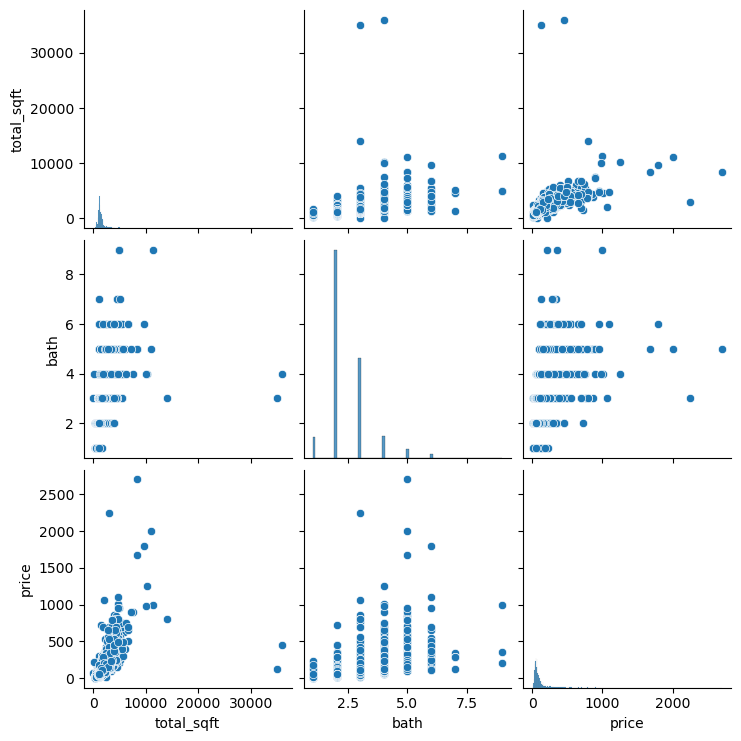

In [9]:
sns.pairplot(df[['total_sqft','bath','price']])
plt.show()

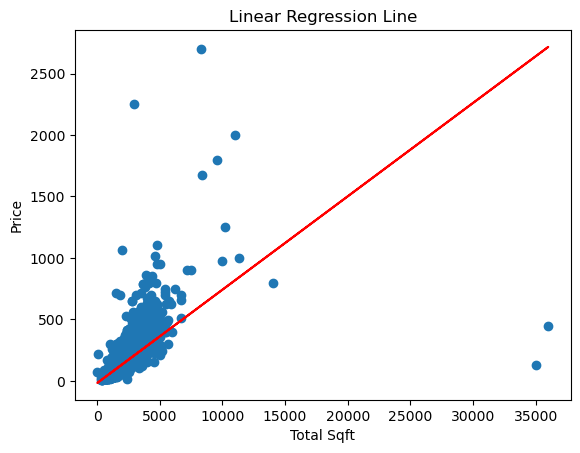

In [10]:
plt.scatter(df['total_sqft'], df['price'])

model_single = LinearRegression()
model_single.fit(df[['total_sqft']], df['price'])

plt.plot(df['total_sqft'], model_single.predict(df[['total_sqft']]), color='red')

plt.xlabel("Total Sqft")
plt.ylabel("Price")
plt.title("Linear Regression Line")

plt.show()